# Monte Carlo Cross-Validation — SPR with 3 training stations

100 random configurations per variable (precip, tmin, tmax), drawn independently.
For each config, 3 stations are randomly selected as training; the rest are test.
Only a metrics summary is saved — no interpolated arrays.

| Variable | Total stations | Train | Test |
|----------|---------------|-------|------|
| Precip   | 15            | 3     | 12   |
| Tmin     | 44            | 3     | 41   |
| Tmax     | 44            | 3     | 41   |

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load data

In [28]:
# RCM data
data_rcm_pr = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_pr_matched.csv",
    index_col=0
)
data_rcm_tasmin = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_tasmin_matched.csv",
    index_col=0
)
data_rcm_tasmax = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Interpolation_finale/Validation_observation/Data_matched/data_rcm_tasmax_matched.csv",
    index_col=0
)

# Observation data (loaded once, never modified in-place)
data_obs_precip_raw = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_precip_2yr_clean.csv",
    index_col=0
)
data_obs_tmin_raw = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_tmin_2yr_clean.csv",
    index_col=0
)
data_obs_tmax_raw = pd.read_csv(
    "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/data_tmax_2yr_clean.csv",
    index_col=0
)

print(f"Precip : {data_obs_precip_raw.shape[1]} stations, {data_obs_precip_raw.shape[0]} days")
print(f"Tmin   : {data_obs_tmin_raw.shape[1]} stations, {data_obs_tmin_raw.shape[0]} days")
print(f"Tmax   : {data_obs_tmax_raw.shape[1]} stations, {data_obs_tmax_raw.shape[0]} days")

Precip : 15 stations, 730 days
Tmin   : 44 stations, 730 days
Tmax   : 44 stations, 730 days


# Data preparation

Precompute:
- `*_for_metrics` : thresholded original obs used for RMSE/MAE/corr computation
- `*_for_spr` : log-transformed version fed into the SPR model (precip only)
- RCM arrays as numpy

In [29]:
# --- RCM grids (numpy) ---
rcm_pr_np = data_rcm_pr.values.astype(float)
rcm_pr_np[rcm_pr_np < 0.5] = 0  # remove noise (same as original notebook)

rcm_tasmin_np = data_rcm_tasmin.values.astype(float)
rcm_tasmax_np = data_rcm_tasmax.values.astype(float)

# --- Precip ---
# For metrics: threshold raw obs at 0.5 (matches data_pr_obs_orig in original notebook)
obs_pr_for_metrics = data_obs_precip_raw.values.astype(float).copy()
obs_pr_for_metrics[obs_pr_for_metrics < 0.5] = 0

# For SPR input: softplus-inverse transform for positivity
obs_pr_for_spr = data_obs_precip_raw.values.astype(float).copy()
obs_pr_for_spr[obs_pr_for_spr <= 1e-5] = 1e-5
obs_pr_for_spr = np.log(np.exp(obs_pr_for_spr) - 1)

# --- Tmin / Tmax ---
obs_tmin_for_spr = data_obs_tmin_raw.values.astype(float).copy()  # no transform needed
obs_tmax_for_spr = data_obs_tmax_raw.values.astype(float).copy()

obs_tmin_for_metrics = obs_tmin_for_spr.copy()
obs_tmax_for_metrics = obs_tmax_for_spr.copy()

n_total_pr     = obs_pr_for_metrics.shape[1]   # 15
n_total_tasmin = obs_tmin_for_metrics.shape[1]  # 44
n_total_tasmax = obs_tmax_for_metrics.shape[1]  # 44

print(f"n_total_pr={n_total_pr}, n_total_tasmin={n_total_tasmin}, n_total_tasmax={n_total_tasmax}")

n_total_pr=15, n_total_tasmin=44, n_total_tasmax=44


# SPR interpolation function

In [30]:
def spr_interp(data_rcm_grid, data_obs_grid, n_spatterns=10, n_jobs=-1, verbose=False):
    """
    SPR interpolation (single generic function, no day skipping).
    data_obs_grid must have NaN columns for stations to interpolate.
    NaN pattern is detected from row 0 and assumed constant across days.
    Returns interpolated array with shape (n_days, n_stations).
    """
    data_rcm_grid = data_rcm_grid.values if isinstance(data_rcm_grid, pd.DataFrame) else data_rcm_grid
    data_obs_grid = data_obs_grid.values if isinstance(data_obs_grid, pd.DataFrame) else data_obs_grid

    if data_rcm_grid.shape[1] != data_obs_grid.shape[1]:
        raise ValueError("RCM and observation grids must have the same number of stations.")
    if n_spatterns > data_rcm_grid.shape[1]:
        raise ValueError("n_spatterns cannot exceed the number of stations.")

    scaler = StandardScaler(with_mean=True, with_std=False)
    data_rcm_scaled = scaler.fit_transform(data_rcm_grid)
    centres_pca = scaler.mean_

    svd_rcm = TruncatedSVD(n_components=n_spatterns, random_state=0)
    svd_rcm.fit(data_rcm_scaled)
    spatterns = svd_rcm.components_.T  # (n_stations, n_spatterns)

    indexes_NA_col = np.where(np.isnan(data_obs_grid[0, :]))[0]
    data_obs_valid = np.delete(data_obs_grid, indexes_NA_col, axis=1)
    spatterns_model = np.delete(spatterns, indexes_NA_col, axis=0)
    centres_model = np.delete(centres_pca, indexes_NA_col)

    nrow_obs = data_obs_grid.shape[0]

    def interpolate_one_day(i):
        obs_day = data_obs_valid[i, :]
        obs_day_centered = obs_day - centres_model
        model = LinearRegression(fit_intercept=False)
        model.fit(spatterns_model, obs_day_centered)
        pattern_weights = model.coef_.reshape(-1, 1)
        reconstructed = spatterns @ pattern_weights + centres_pca.reshape(-1, 1)
        return reconstructed.ravel()

    iterator = tqdm(range(nrow_obs), desc="Interp") if verbose else range(nrow_obs)
    interp_vals = Parallel(n_jobs=n_jobs)(delayed(interpolate_one_day)(i) for i in iterator)
    return np.vstack(interp_vals)

# Metric functions

In [31]:
def mean_daily_rmse(mod, obs):
    """Spatial RMSE: per-day sqrt(mean_stations(err²)), then averaged over days."""
    M = np.asarray(mod, dtype=float)
    O = np.asarray(obs, dtype=float)
    daily_rmse = np.sqrt(np.nanmean((M - O) ** 2, axis=1))  # (n_days,)
    return float(np.nanmean(daily_rmse))


def mean_station_ssim(mod, obs, K1=0.01, K2=0.03, L=None, eps=1e-12):
    """
    SSIM averaged over stations (each station computed over its full time series).
    Dynamic range L is taken per station from obs if not provided.
    """
    M = np.asarray(mod, dtype=float)
    O = np.asarray(obs, dtype=float)
    station_ssim = []
    for s in range(M.shape[1]):
        a, b = M[:, s], O[:, s]
        mask = np.isfinite(a) & np.isfinite(b)
        if mask.sum() < 2:
            station_ssim.append(np.nan)
            continue
        a, b = a[mask], b[mask]

        mu_a, mu_b   = a.mean(), b.mean()
        var_a        = np.mean((a - mu_a) ** 2)
        var_b        = np.mean((b - mu_b) ** 2)
        sig_a, sig_b = np.sqrt(var_a), np.sqrt(var_b)
        cov_ab       = np.mean((a - mu_a) * (b - mu_b))

        if L is None:
            L_s = np.max(b) - np.min(b)
            if L_s < eps:
                L_s = max(abs(mu_b), eps)
        else:
            L_s = L

        C1 = (K1 * L_s) ** 2
        C2 = (K2 * L_s) ** 2
        C3 = C2 / 2.0

        l = (2 * mu_a * mu_b + C1)   / (mu_a**2 + mu_b**2 + C1)
        c = (2 * sig_a * sig_b + C2) / (var_a + var_b + C2)
        s = (cov_ab + C3)            / (sig_a * sig_b + C3)

        station_ssim.append(l * c * s)

    return float(np.nanmean(station_ssim))


def interday_variability(arr):
    """
    Inter-day variability: mean_stations(|Y[t,j] - Y[t-1,j]|), averaged over t.
    Returns a single scalar.
    """
    A = np.asarray(arr, dtype=float)
    delta = np.nanmean(np.abs(np.diff(A, axis=0)), axis=1)  # (T-1,)
    return float(np.nanmean(delta))


def mean_acf_lag1(arr):
    """ACF at lag 1 averaged over stations."""
    A = np.asarray(arr, dtype=float)
    acf_vals = []
    for s in range(A.shape[1]):
        x = A[:, s]
        mask = np.isfinite(x)
        if mask.sum() < 3:
            continue
        x = x[mask]
        x_c = x - x.mean()
        var = np.mean(x_c ** 2)
        if var < 1e-12:
            continue
        acf_vals.append(float(np.mean(x_c[:-1] * x_c[1:]) / var))
    return float(np.nanmean(acf_vals)) if acf_vals else np.nan


# Monte Carlo settings

In [32]:
N_CONFIGS   = 100  # number of random configurations
N_TRAIN     = 3    # training stations (same for all variables)
N_SPATTERNS = 2    # spatial patterns (chosen previously)

# Evaluation period: exclude days 0:365 from test metrics
# Python slice [365:730] = days 365..729 (second year if total is 730 days).
EVAL_DAY_SLICE = slice(365, 730)

# Seeds 0..99 — full reproducibility
SEEDS = list(range(N_CONFIGS))

# Dry-day threshold for precip (in transformed space).
# log(exp(0.5) - 1) ≈ -0.43 : values at or below this correspond to < 0.5 mm/day (noise floor).
# Days where ALL 3 training stations are <= this are skipped to avoid overflow.
PR_DRY_THRESHOLD = float(np.log(np.exp(0.5) - 1))
print(f"PR_DRY_THRESHOLD (transformed space) = {PR_DRY_THRESHOLD:.4f}")
print(f"Evaluation days used for metrics: {EVAL_DAY_SLICE.start}:{EVAL_DAY_SLICE.stop}")

PR_DRY_THRESHOLD (transformed space) = -0.4328
Evaluation days used for metrics: 365:730


# Precipitation — 100 configurations
12 stations held out as test, 3 as training.

In [33]:
results_pr = []

for seed in tqdm(SEEDS, desc="PRECIP"):
    np.random.seed(seed)
    train_idx = np.sort(np.random.choice(n_total_pr, size=N_TRAIN, replace=False))
    test_idx  = np.array([i for i in range(n_total_pr) if i not in train_idx])

    obs_mc = obs_pr_for_spr.copy()
    obs_mc[:, test_idx] = np.nan

    interp = spr_interp(
        rcm_pr_np[EVAL_DAY_SLICE,:], obs_mc[EVAL_DAY_SLICE,:],
        n_spatterns=N_SPATTERNS, n_jobs=-1,
        verbose=False
    )

    # Inverse transform: stable softplus + noise threshold
    interp_bt = np.logaddexp(0, interp)
    interp_bt[interp_bt < 0.5] = 0

    # Metrics are computed only on test indexes and evaluation day window
    pred = interp_bt[:, test_idx]
    obs  = obs_pr_for_metrics[EVAL_DAY_SLICE, :][:, test_idx]

    results_pr.append({
        'config'        : seed,
        'rmse_s'        : mean_daily_rmse(pred, obs),
        'ssim'          : mean_station_ssim(pred, obs),
        'interday_mod'  : interday_variability(pred),
        'interday_obs'  : interday_variability(obs),
        'acf_lag1_mod'  : mean_acf_lag1(pred),
        'acf_lag1_obs'  : mean_acf_lag1(obs),
        'train_stations': list(data_obs_precip_raw.columns[train_idx]),
        'test_stations' : list(data_obs_precip_raw.columns[test_idx])
    })

results_pr_df = pd.DataFrame(results_pr)
print("\nPRECIP summary:")
print(results_pr_df[['rmse_s', 'ssim', 'interday_mod', 'interday_obs', 'acf_lag1_mod', 'acf_lag1_obs']].describe().round(4))

PRECIP: 100%|██████████| 100/100 [00:07<00:00, 13.97it/s]


PRECIP summary:
         rmse_s      ssim  interday_mod  interday_obs  acf_lag1_mod  \
count  100.0000  100.0000      100.0000      100.0000      100.0000   
mean     3.5606    0.6262        4.9286        4.1555        0.0588   
std      3.0719    0.0933        2.9936        0.0605        0.0322   
min      2.2764    0.2162        3.2146        3.9820       -0.0219   
25%      2.5928    0.6067        3.9758        4.1184        0.0411   
50%      2.9252    0.6444        4.3536        4.1599        0.0553   
75%      3.4319    0.6903        4.8340        4.2008        0.0776   
max     26.4727    0.7339       28.8367        4.2690        0.1330   

       acf_lag1_obs  
count      100.0000  
mean         0.0508  
std          0.0050  
min          0.0384  
25%          0.0469  
50%          0.0515  
75%          0.0542  
max          0.0609  


# Tmin — 100 configurations
41 stations held out as test, 3 as training.

In [34]:
results_tmin = []

for seed in tqdm(SEEDS, desc="TMIN"):
    np.random.seed(seed)
    train_idx = np.sort(np.random.choice(n_total_tasmin, size=N_TRAIN, replace=False))
    test_idx  = np.array([i for i in range(n_total_tasmin) if i not in train_idx])

    obs_mc = obs_tmin_for_spr.copy()
    obs_mc[:, test_idx] = np.nan

    interp = spr_interp(rcm_tasmin_np[EVAL_DAY_SLICE,:], obs_mc[EVAL_DAY_SLICE,:],
                        n_spatterns=N_SPATTERNS, n_jobs=-1,
                        verbose=False)

    pred = interp[:, test_idx]
    obs  = obs_tmin_for_metrics[EVAL_DAY_SLICE, :][:, test_idx]

    results_tmin.append({
        'config'        : seed,
        'rmse_s'        : mean_daily_rmse(pred, obs),
        'ssim'          : mean_station_ssim(pred, obs),
        'interday_mod'  : interday_variability(pred),
        'interday_obs'  : interday_variability(obs),
        'acf_lag1_mod'  : mean_acf_lag1(pred),
        'acf_lag1_obs'  : mean_acf_lag1(obs),
        'train_stations': list(data_obs_tmin_raw.columns[train_idx]),
        'test_stations' : list(data_obs_tmin_raw.columns[test_idx])
    })

results_tmin_df = pd.DataFrame(results_tmin)
print("\nTMIN summary:")
print(results_tmin_df[['rmse_s', 'ssim', 'interday_mod', 'interday_obs', 'acf_lag1_mod', 'acf_lag1_obs']].describe().round(4))

TMIN: 100%|██████████| 100/100 [00:07<00:00, 12.58it/s]


TMIN summary:
         rmse_s      ssim  interday_mod  interday_obs  acf_lag1_mod  \
count  100.0000  100.0000      100.0000      100.0000      100.0000   
mean     3.4793    0.4972        4.4740        3.8513        0.8616   
std      2.1001    0.1574        1.5371        0.0231        0.0716   
min      2.2294    0.0570        2.9893        3.7984        0.4784   
25%      2.4420    0.3934        3.5999        3.8337        0.8555   
50%      2.6676    0.5746        3.8910        3.8484        0.8876   
75%      3.6622    0.6074        4.6704        3.8674        0.8983   
max     14.7525    0.6761       11.9968        3.9087        0.9287   

       acf_lag1_obs  
count      100.0000  
mean         0.8888  
std          0.0011  
min          0.8863  
25%          0.8882  
50%          0.8889  
75%          0.8896  
max          0.8914  


# Tmax — 100 configurations
41 stations held out as test, 3 as training.

In [35]:
results_tmax = []

for seed in tqdm(SEEDS, desc="TMAX"):
    np.random.seed(seed)
    train_idx = np.sort(np.random.choice(n_total_tasmax, size=N_TRAIN, replace=False))
    test_idx  = np.array([i for i in range(n_total_tasmax) if i not in train_idx])

    obs_mc = obs_tmax_for_spr.copy()
    obs_mc[:, test_idx] = np.nan

    interp = spr_interp(rcm_tasmax_np[EVAL_DAY_SLICE,:], obs_mc[EVAL_DAY_SLICE,:],
                        n_spatterns=N_SPATTERNS, n_jobs=-1,
                        verbose=False)

    pred = interp[:, test_idx]
    obs  = obs_tmax_for_metrics[EVAL_DAY_SLICE, :][:, test_idx]

    results_tmax.append({
        'config'        : seed,
        'rmse_s'        : mean_daily_rmse(pred, obs),
        'ssim'          : mean_station_ssim(pred, obs),
        'interday_mod'  : interday_variability(pred),
        'interday_obs'  : interday_variability(obs),
        'acf_lag1_mod'  : mean_acf_lag1(pred),
        'acf_lag1_obs'  : mean_acf_lag1(obs),
        'train_stations': list(data_obs_tmax_raw.columns[train_idx]),
        'test_stations' : list(data_obs_tmax_raw.columns[test_idx])
    })

results_tmax_df = pd.DataFrame(results_tmax)
print("\nTMAX summary:")
print(results_tmax_df[['rmse_s', 'ssim', 'interday_mod', 'interday_obs', 'acf_lag1_mod', 'acf_lag1_obs']].describe().round(4))

TMAX: 100%|██████████| 100/100 [00:08<00:00, 11.73it/s]


TMAX summary:
         rmse_s      ssim  interday_mod  interday_obs  acf_lag1_mod  \
count  100.0000  100.0000      100.0000      100.0000      100.0000   
mean     2.4716    0.9684        4.2762        3.7143        0.9142   
std      2.1100    0.0685        1.9104        0.0096        0.0530   
min      1.4598    0.4202        3.5120        3.6889        0.5815   
25%      1.6068    0.9767        3.6168        3.7090        0.9214   
50%      1.8755    0.9867        3.7447        3.7141        0.9322   
75%      2.3651    0.9907        4.0195        3.7203        0.9362   
max     18.1453    0.9925       19.4145        3.7357        0.9412   

       acf_lag1_obs  
count      100.0000  
mean         0.9331  
std          0.0003  
min          0.9325  
25%          0.9329  
50%          0.9331  
75%          0.9333  
max          0.9339  


# Save metrics (no interpolated arrays)

In [36]:
SAVE_DIR = "/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/"

results_pr_df.to_csv(  SAVE_DIR + "metrics_pr_ols.csv",   index=False)
results_tmin_df.to_csv(SAVE_DIR + "metrics_tmin_ols.csv", index=False)
results_tmax_df.to_csv(SAVE_DIR + "metrics_tmax_ols.csv", index=False)

print("Metrics saved.")

Metrics saved.


# Visualization — distribution of average metrics across 100 configurations

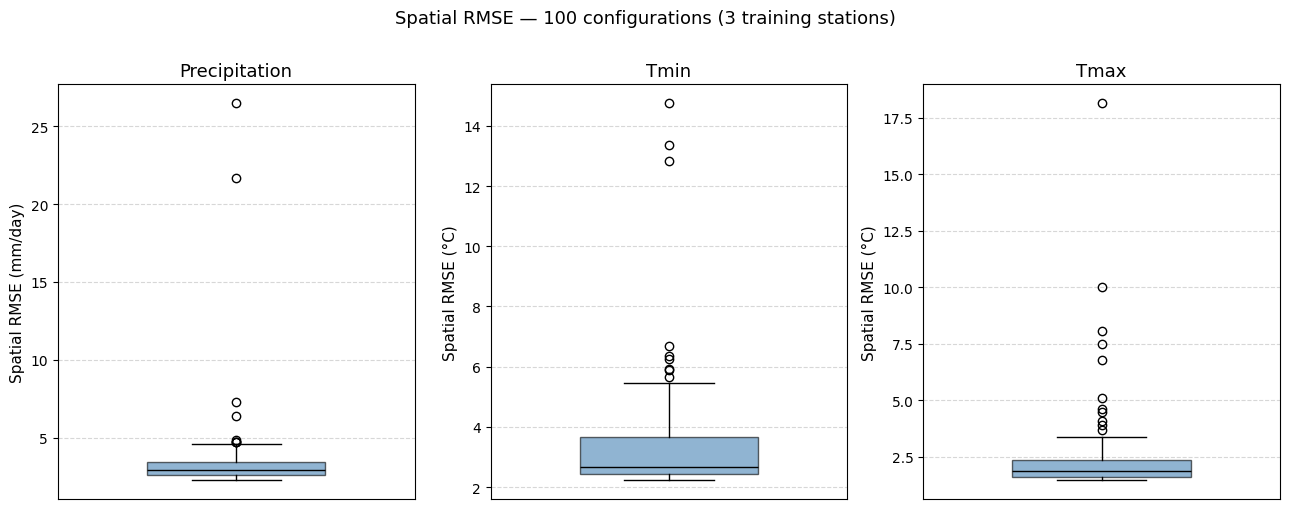

In [37]:
# ---- Spatial RMSE distribution (one panel per variable) ----
variable_info = [
    (results_pr_df,   "Precipitation", "mm/day"),
    (results_tmin_df, "Tmin",          "\u00b0C"),
    (results_tmax_df, "Tmax",          "\u00b0C"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)
for ax, (df, name, unit) in zip(axes, variable_info):
    ax.boxplot(df['rmse_s'], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black'))
    ax.set_title(name, fontsize=13)
    ax.set_ylabel(f"Spatial RMSE ({unit})", fontsize=11)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Spatial RMSE \u2014 100 configurations (3 training stations)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


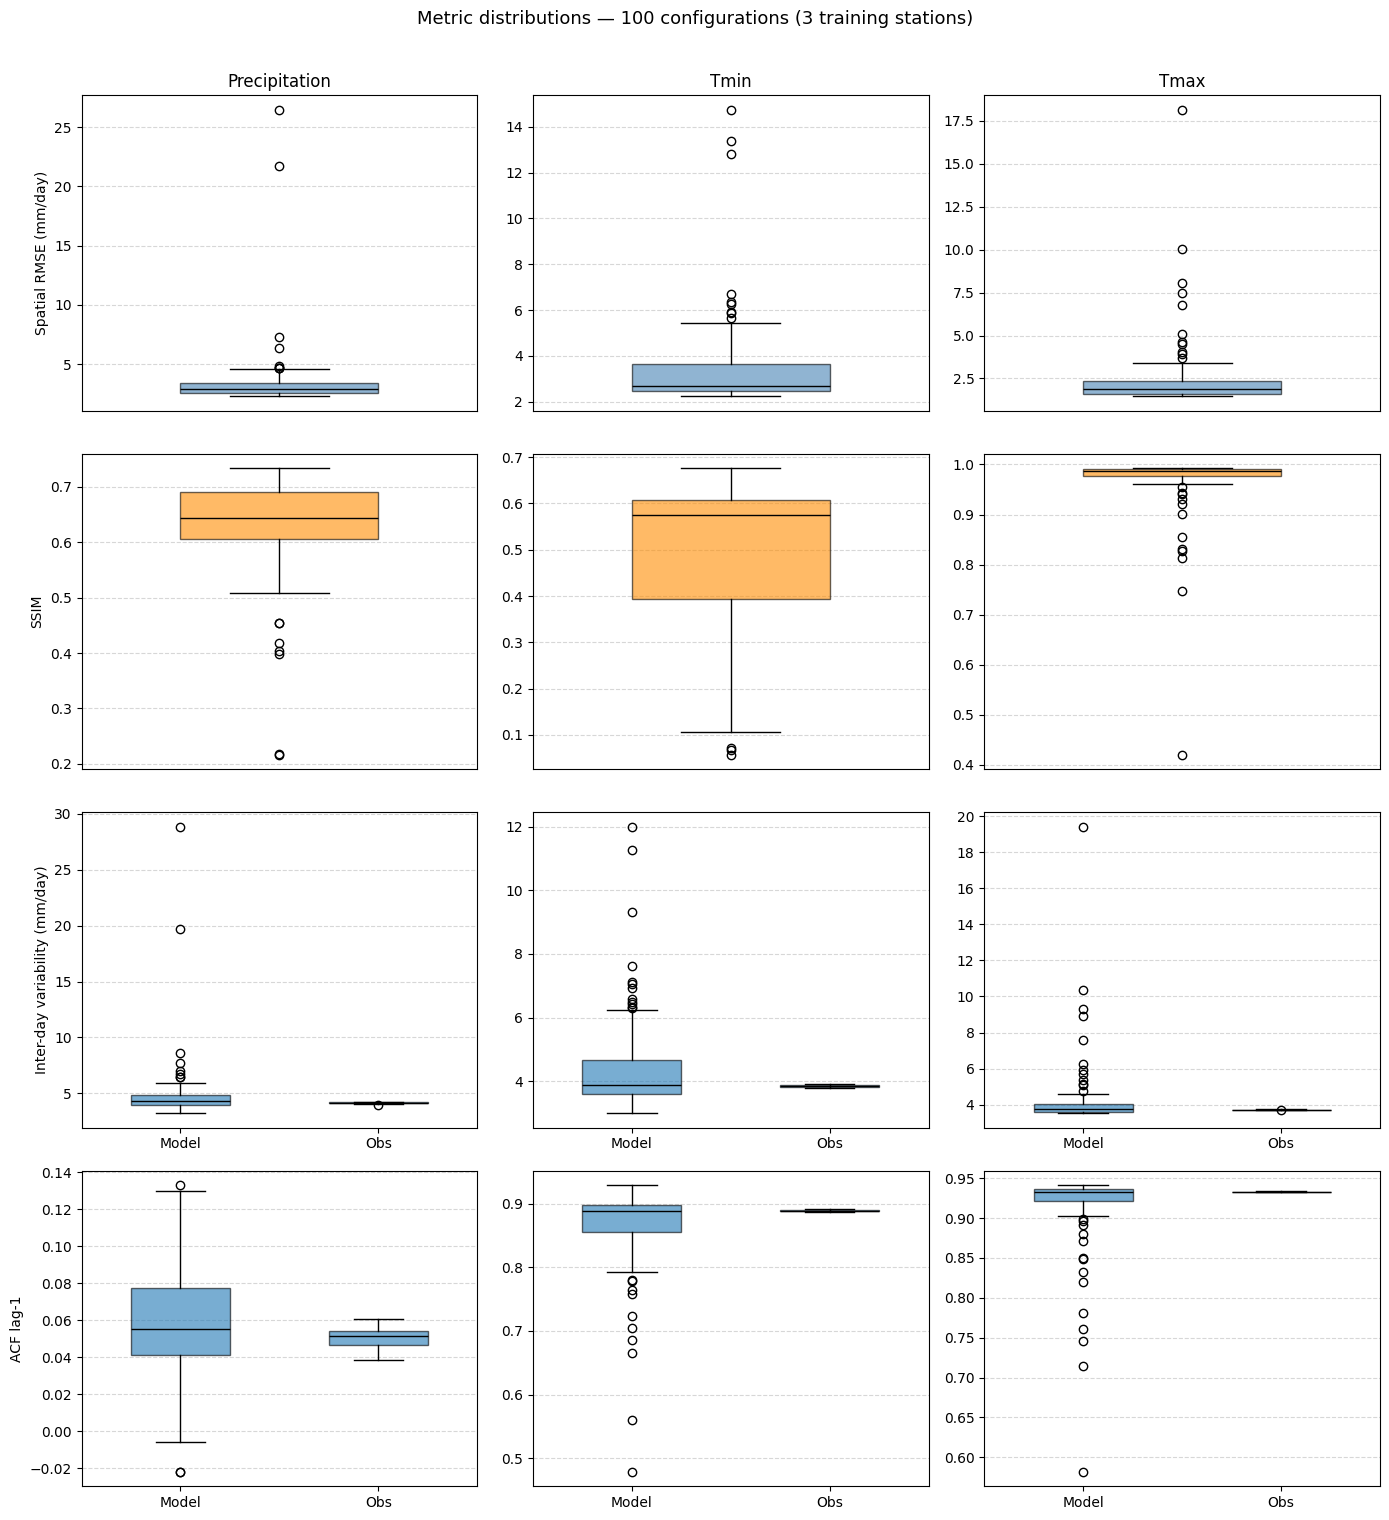

In [38]:
fig, axes = plt.subplots(4, 3, figsize=(14, 15))

for col, (df, name, unit) in enumerate(variable_info):

    # Row 0: Spatial RMSE
    ax = axes[0, col]
    ax.boxplot(df['rmse_s'], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black'))
    ax.set_title(name, fontsize=12)
    if col == 0:
        ax.set_ylabel(f"Spatial RMSE ({unit})", fontsize=10)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Row 1: SSIM
    ax = axes[1, col]
    ax.boxplot(df['ssim'], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='darkorange', alpha=0.6),
               medianprops=dict(color='black'))
    if col == 0:
        ax.set_ylabel("SSIM", fontsize=10)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Row 2: Inter-day variability (model vs obs)
    ax = axes[2, col]
    ax.boxplot(
        [df['interday_mod'], df['interday_obs']],
        labels=['Model', 'Obs'],
        widths=0.5, patch_artist=True,
        boxprops=dict(alpha=0.6),
        medianprops=dict(color='black')
    )
    if col == 0:
        ax.set_ylabel(f"Inter-day variability ({unit})", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Row 3: ACF lag-1 (model vs obs)
    ax = axes[3, col]
    ax.boxplot(
        [df['acf_lag1_mod'], df['acf_lag1_obs']],
        labels=['Model', 'Obs'],
        widths=0.5, patch_artist=True,
        boxprops=dict(alpha=0.6),
        medianprops=dict(color='black')
    )
    if col == 0:
        ax.set_ylabel("ACF lag-1", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Metric distributions — 100 configurations (3 training stations)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
